In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [2]:
df = pd.read_csv('/Users/othree/Cognitive Reserve Modeling/Data/ADNI_master_merged_12-17-2025.csv')

In [3]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
corr_matrix

,Image Data ID,Age,DX2,RID,SITE,AGE,PTEDUCAT,APOE4,FDG,PIB,...,ID,SITEID,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,ADNI_MEM,ADNI_EF,ADNI_LAN,ADNI_VS,ADNI_EF2
Image Data ID,1.000000,0.026730,-0.162395,0.684357,0.012898,-0.111041,0.087624,-0.077865,0.104389,0.146052,...,0.528566,0.024536,NaN,NaN,NaN,0.019217,0.014895,0.021183,0.003933,0.012291
Age,0.026730,1.000000,-0.003198,-0.143216,0.022377,0.963790,-0.057304,-0.166993,-0.068929,-0.035052,...,0.104907,-0.019782,NaN,NaN,NaN,0.009279,-0.058395,-0.053132,0.042026,-0.046198
DX2,-0.162395,-0.003198,1.000000,-0.109488,-0.065919,0.016758,-0.134462,0.352587,-0.581457,0.245440,...,0.107209,-0.065022,NaN,NaN,NaN,-0.748101,-0.630002,-0.607584,-0.380522,-0.597198
RID,0.684357,-0.143216,-0.109488,1.000000,0.022406,-0.105757,0.094984,-0.035240,0.095379,0.055342,...,0.388774,0.027205,NaN,NaN,NaN,-0.126411,-0.168400,-0.162296,-0.053187,-0.150954
SITE,0.012898,0.022377,-0.065919,0.022406,1.000000,0.023210,0.009204,-0.051713,0.028545,-0.203825,...,0.028842,0.350603,NaN,NaN,NaN,0.089974,0.029019,0.024574,0.016112,0.027602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ADNI_MEM,0.019217,0.009279,-0.748101,-0.126411,0.089974,0.010444,0.157040,-0.308089,0.552793,-0.318121,...,-0.091081,0.188096,NaN,NaN,NaN,1.000000,0.714841,0.743490,0.430868,0.665696
ADNI_EF,0.014895,-0.058395,-0.630002,-0.168400,0.029019,-0.062730,0.213896,-0.206406,0.625417,-0.185836,...,-0.064822,0.063555,NaN,NaN,NaN,0.714841,1.000000,0.769312,0.587896,0.981553
ADNI_LAN,0.021183,-0.053132,-0.607584,-0.162296,0.024574,-0.053966,0.200546,-0.209434,0.468766,-0.239119,...,-0.089969,0.090129,NaN,NaN,NaN,0.743490,0.769312,1.000000,0.474558,0.680028
ADNI_VS,0.003933,0.042026,-0.380522,-0.053187,0.016112,0.044749,0.183495,-0.135681,0.376081,-0.110369,...,-0.048988,0.003704,NaN,NaN,NaN,0.430868,0.587896,0.474558,1.000000,0.591846


In [4]:
# 상삼각 행렬만 추출 (중복 제거)
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'correlation']
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
corr_pairs = corr_pairs.sort_values('abs_corr', ascending=False)

print(f"총 변수 수: {len(numeric_df.columns)}")
print(f"총 변수 쌍 수: {len(corr_pairs)}")
print()
print("=== 상관 높은 TOP 30 ===")
print(corr_pairs.head(30).to_string(index=False))
print()
print("=== 상관 낮은 BOTTOM 30 (거의 무관) ===")
print(corr_pairs.tail(30).to_string(index=False))

총 변수 수: 118
총 변수 쌍 수: 5386

=== 상관 높은 TOP 30 ===
           var1            var2  correlation  abs_corr
  Image Data ID        IMAGEUID     1.000000  1.000000
       Years_bl        Month_bl     1.000000  1.000000
       Years_bl           Month     0.999619  0.999619
       Month_bl           Month     0.999619  0.999619
       Years_bl               M     0.999129  0.999129
       Month_bl               M     0.999129  0.999129
          Month               M     0.999078  0.999078
            ICV          ICV_bl     0.990326  0.990326
  mPACCdigit_bl mPACCtrailsB_bl     0.983230  0.983230
         ADAS11          ADAS13     0.982106  0.982106
        ADNI_EF        ADNI_EF2     0.981553  0.981553
     mPACCdigit    mPACCtrailsB     0.979005  0.979005
      ADAS11_bl       ADAS13_bl     0.975982  0.975982
     Ventricles   Ventricles_bl     0.974658  0.974658
           AV45         AV45_bl     0.973875  0.973875
     WholeBrain   WholeBrain_bl     0.972792  0.972792
            Age 

In [5]:
TIME_VARS = {'Years_bl', 'Month_bl', 'Month', 'M'}
ADMIN_VARS = {'RID', 'IMAGEUID', 'IMAGEUID_bl', 'Image Data ID', 'ID', 'SITEID', 'SITE',
              'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'AGE',
              'VSWTUNIT', 'VSTMPSRC', 'VSTMPUNT', 'VSHTUNIT', 'VSHGTSC', 'DX2'}

ECOG_SP_SUBS = {'EcogSPMem','EcogSPLang','EcogSPVisspat','EcogSPPlan','EcogSPOrgan','EcogSPDivatt'}
ECOG_PT_SUBS = {'EcogPtMem','EcogPtLang','EcogPtVisspat','EcogPtPlan','EcogPtOrgan','EcogPtDivatt'}
ECOG_TOTALS  = {'EcogSPTotal','EcogPtTotal'}

SAME_TEST_GROUPS = [
    {'ADAS11', 'ADAS13'},
    {'ADAS11_bl', 'ADAS13_bl'},
    {'ADNI_EF', 'ADNI_EF2'},
    {'mPACCdigit', 'mPACCtrailsB'},
    {'mPACCdigit_bl', 'mPACCtrailsB_bl'},
]

def is_obvious(row):
    v1, v2 = row['var1'], row['var2']
    if v1 in ADMIN_VARS or v2 in ADMIN_VARS: return True
    if v1 in TIME_VARS  or v2 in TIME_VARS:  return True
    if v1 + '_bl' == v2 or v2 + '_bl' == v1: return True
    if v1 + '_BL' == v2 or v2 + '_BL' == v1: return True
    v1b, v2b = v1.replace('_bl',''), v2.replace('_bl','')
    if (v1b in ECOG_SP_SUBS and v2b in ECOG_TOTALS) or (v2b in ECOG_SP_SUBS and v1b in ECOG_TOTALS): return True
    if (v1b in ECOG_PT_SUBS and v2b in ECOG_TOTALS) or (v2b in ECOG_PT_SUBS and v1b in ECOG_TOTALS): return True
    if v1b in ECOG_SP_SUBS and v2b in ECOG_SP_SUBS: return True
    if v1b in ECOG_PT_SUBS and v2b in ECOG_PT_SUBS: return True
    for grp in SAME_TEST_GROUPS:
        if v1 in grp and v2 in grp: return True
    return False

filtered_pairs = corr_pairs[~corr_pairs.apply(is_obvious, axis=1)]
print('=== Obvious 제거 후 TOP 30 ===')
filtered_pairs.head(30)

=== Obvious 제거 후 TOP 30 ===


,var1,var2,correlation,abs_corr
1663,RAVLT_immediate,ADNI_MEM,0.940877,0.940877
2086,DIGITSCOR,ADNI_EF2,0.940089,0.940089
1512,MMSE,mPACCdigit,0.930691,0.930691
1513,MMSE,mPACCtrailsB,0.923409,0.923409
1323,ADAS13,mPACCdigit,-0.920335,0.920335
1324,ADAS13,mPACCtrailsB,-0.914960,0.914960
2188,FAQ,EcogSPTotal,0.910854,0.910854
2083,DIGITSCOR,ADNI_EF,0.905989,0.905989
4087,MMSE_bl,mPACCdigit_bl,0.904000,0.904000
4507,FAQ_bl,EcogSPTotal_bl,0.900413,0.900413


In [6]:
print('=== Obvious 제거 후 BOTTOM 30 (연관 제일 없는 쌍) ===')
bottom30 = filtered_pairs.dropna(subset=['correlation']).sort_values('abs_corr').head(30)
print(bottom30.to_string(index=False))

=== Obvious 제거 후 BOTTOM 30 (연관 제일 없는 쌍) ===
                    var1             var2  correlation  abs_corr
                     FAQ           VSRESP     0.000121  0.000121
                     Age        ADASQ4_bl    -0.000163  0.000163
                 VSPULSE          ADNI_VS     0.000475  0.000475
     RAVLT_forgetting_bl      TRABSCOR_bl     0.000491  0.000491
                     Age        ADAS11_bl     0.000562  0.000562
                  FDG_bl           VSTEMP     0.000572  0.000572
                  ICV_bl   EcogSPTotal_bl     0.001037  0.001037
RAVLT_perc_forgetting_bl          VSBPDIA    -0.001137  0.001137
                   CDRSB          VSBPDIA     0.001144  0.001144
                  ADASQ4          VSBPDIA    -0.001183  0.001183
                     Age        LDELTOTAL    -0.001227  0.001227
     RAVLT_forgetting_bl          VSBPDIA     0.001271  0.001271
            EcogPtDivatt       WholeBrain    -0.001288  0.001288
               ADAS13_bl          VSBPDIA     

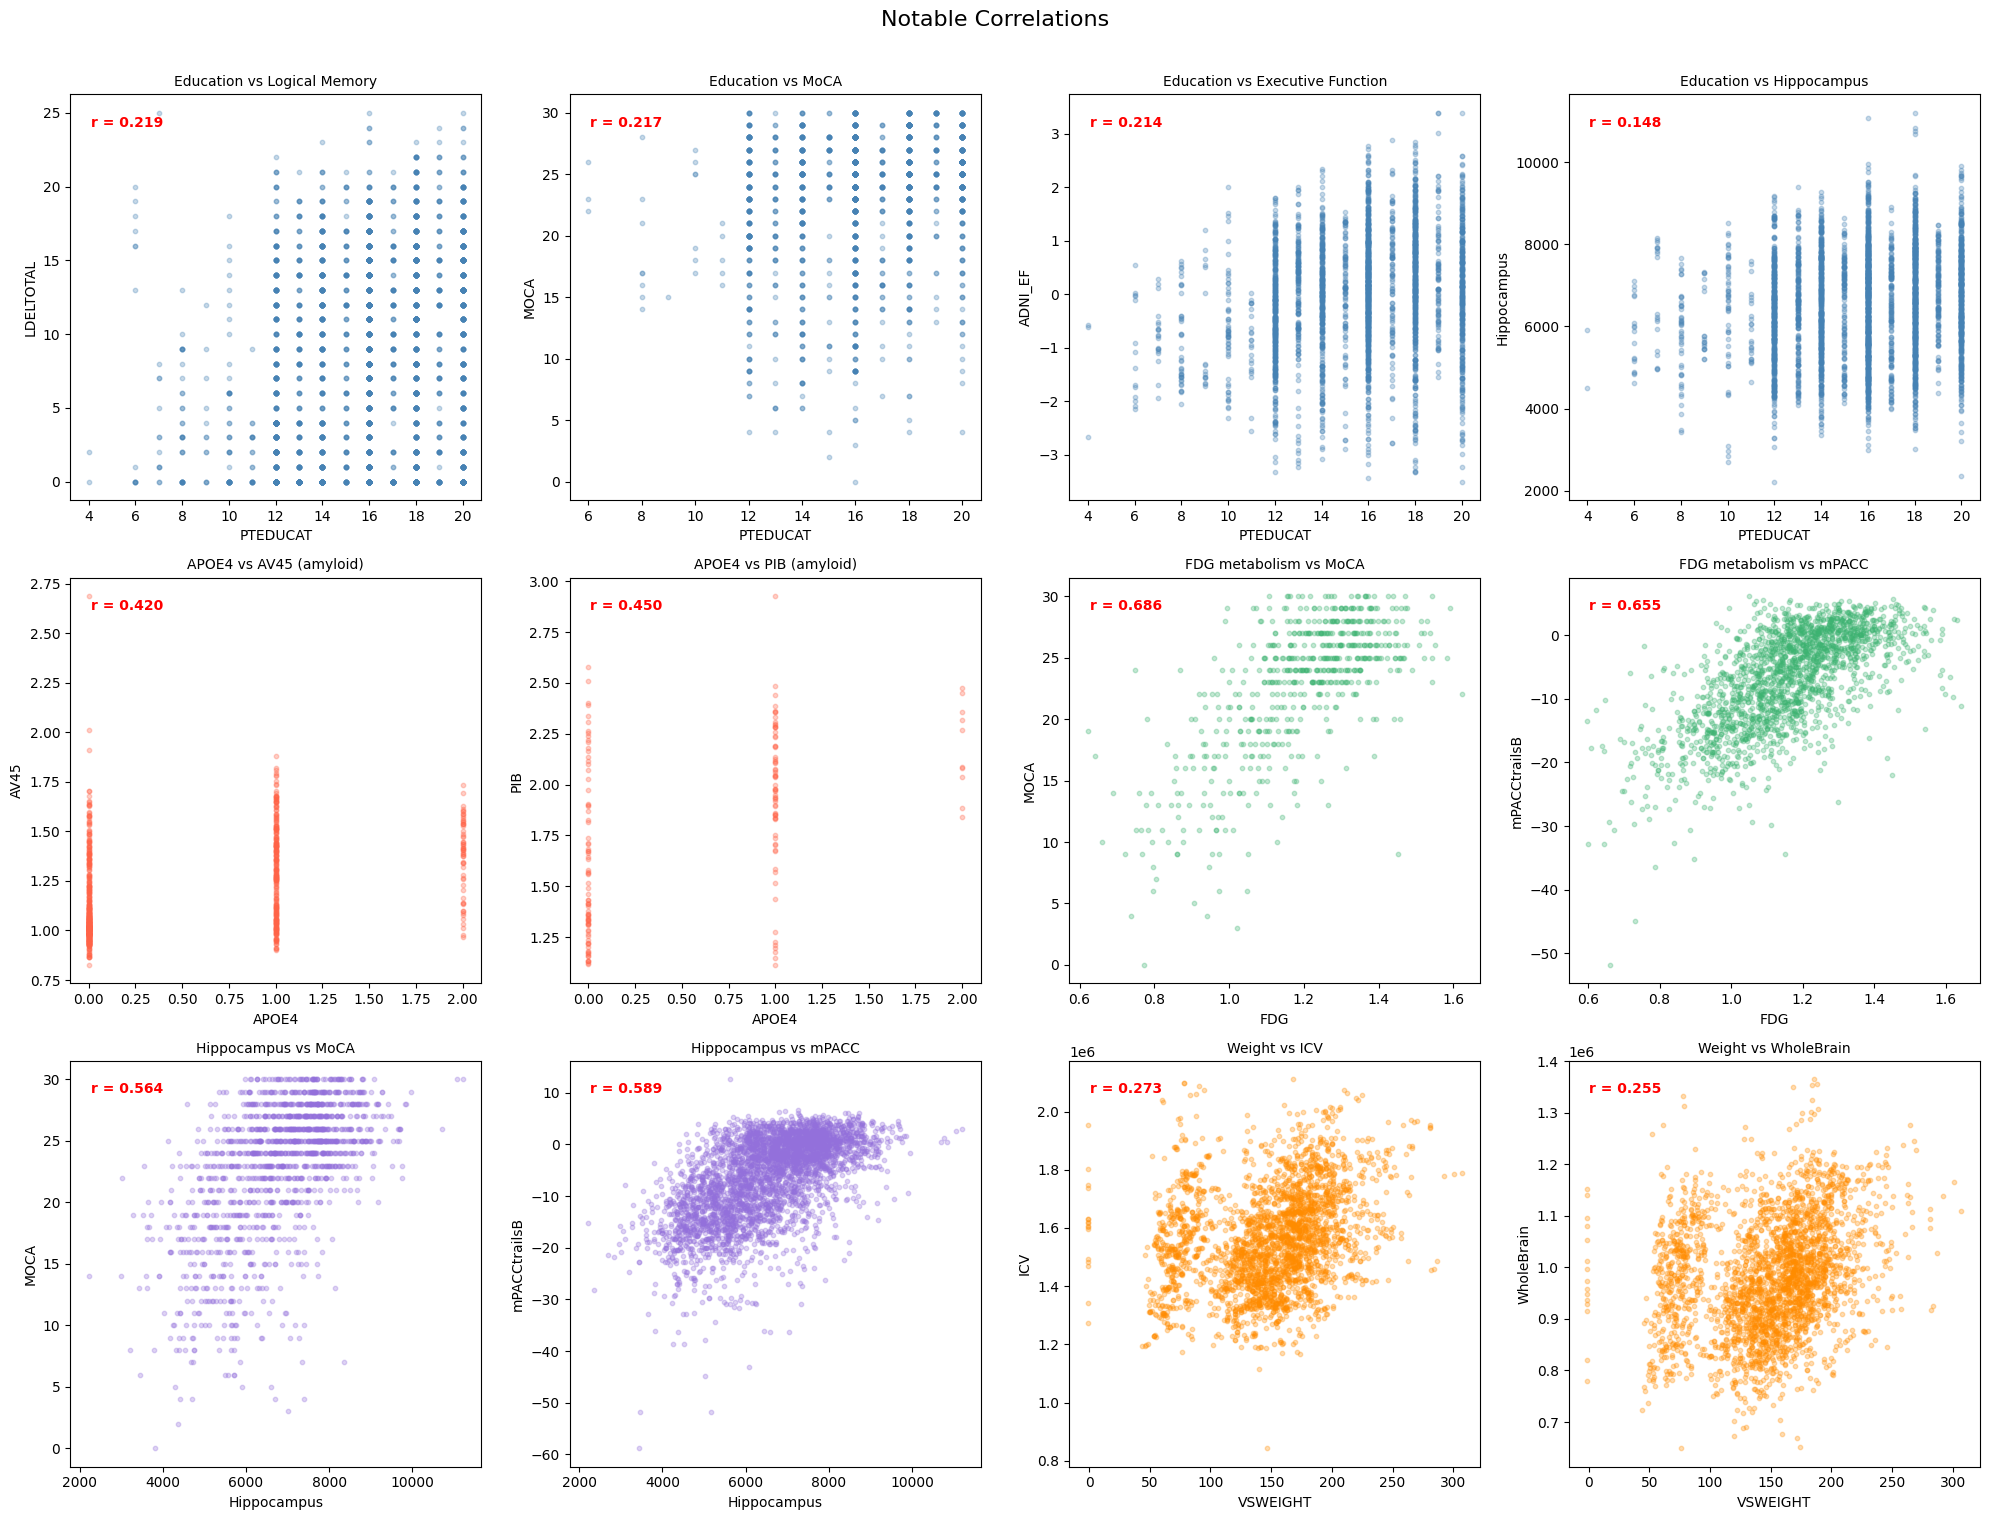

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Notable Correlations', fontsize=16, y=1.01)

def scatter(ax, x_var, y_var, title=None, color='steelblue'):
    data = df[[x_var, y_var]].dropna()
    ax.scatter(data[x_var], data[y_var], alpha=0.3, s=10, color=color)
    r = data[[x_var, y_var]].corr().iloc[0, 1]
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(title or f'{x_var} vs {y_var}', fontsize=10)
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10,
                color='red', fontweight='bold')

# 1. PTEDUCAT vs cognition
scatter(axes[0,0], 'PTEDUCAT', 'LDELTOTAL', 'Education vs Logical Memory', 'steelblue')
scatter(axes[0,1], 'PTEDUCAT', 'MOCA', 'Education vs MoCA', 'steelblue')
scatter(axes[0,2], 'PTEDUCAT', 'ADNI_EF', 'Education vs Executive Function', 'steelblue')
scatter(axes[0,3], 'PTEDUCAT', 'Hippocampus', 'Education vs Hippocampus', 'steelblue')

# 2. APOE4 vs amyloid
scatter(axes[1,0], 'APOE4', 'AV45', 'APOE4 vs AV45 (amyloid)', 'tomato')
scatter(axes[1,1], 'APOE4', 'PIB', 'APOE4 vs PIB (amyloid)', 'tomato')

# 3. FDG vs cognition vs structure
scatter(axes[1,2], 'FDG', 'MOCA', 'FDG metabolism vs MoCA', 'mediumseagreen')
scatter(axes[1,3], 'FDG', 'mPACCtrailsB', 'FDG metabolism vs mPACC', 'mediumseagreen')

# 4. FDG vs Hippocampus (structure vs metabolism 비교용)
scatter(axes[2,0], 'Hippocampus', 'MOCA', 'Hippocampus vs MoCA', 'mediumpurple')
scatter(axes[2,1], 'Hippocampus', 'mPACCtrailsB', 'Hippocampus vs mPACC', 'mediumpurple')

# 5. Weight vs brain size
scatter(axes[2,2], 'VSWEIGHT', 'ICV', 'Weight vs ICV', 'darkorange')
scatter(axes[2,3], 'VSWEIGHT', 'WholeBrain', 'Weight vs WholeBrain', 'darkorange')

plt.tight_layout()
plt.show()